In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
# Read the CSV and parse dates
merged_df = pd.read_csv('merged_data.csv', parse_dates=['Date'])
merged_df.set_index('Date', inplace=True)

# Select date range
start_date = '2017-01-01'
end_date = '2018-12-31'
merged_df = merged_df[(merged_df.index >= start_date) & (merged_df.index <= end_date)]

In [3]:
# Convert all to numeric
prices = merged_df.apply(pd.to_numeric, errors='coerce')

# Drop rows with empty or NaN values
prices = prices.dropna()

# Check
prices.head(5)

,V,C,CG,BAC,CB,PYPL,AXP,DFS,CME,USB,...,MS-PF,JPM,FDS,APAM,MMC,BX,KKR,ARES,MFG,BLK
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-03,77.806038,56.437824,12.426118,21.159664,122.881004,40.250000,71.389961,67.974983,105.992722,47.014038,...,21.069468,81.158020,159.099380,23.660036,63.588482,22.124331,14.533012,15.465710,3.205784,341.969910
2017-01-05,79.362129,56.204956,13.657187,21.300541,121.873413,41.060001,71.665886,68.133881,97.869164,46.566376,...,21.554190,76.358383,162.702606,22.696674,64.000732,23.933929,15.065492,15.714490,3.294587,331.320923
2017-01-06,80.458282,56.400562,13.850858,21.300541,122.526459,41.450001,71.808617,67.348793,98.859245,46.867859,...,21.814419,72.850075,164.494583,22.696674,64.347397,24.004742,15.359272,15.797414,3.276827,359.799683
2017-01-09,80.008072,56.093182,16.586140,21.178444,121.761436,41.400002,72.179688,66.937553,106.532440,46.657742,...,22.036579,80.870407,163.588959,22.542542,63.522896,23.973269,15.735682,14.968152,3.241306,369.329346
2017-01-11,80.057022,55.850990,17.454935,21.666819,121.621513,41.279999,73.178757,66.965591,115.471291,47.315533,...,21.614103,89.521812,163.242126,22.696674,63.185616,23.768707,15.836669,14.719372,3.294587,410.931274


In [4]:
stocks = prices.columns
returns = prices.pct_change().dropna()
log_prices = np.log(prices)
log_returns = log_prices.diff().dropna()

form_start = '2017-01-01'
form_end = '2017-12-31'

trade_start = '2018-01-01'
trade_end = '2018-12-31'

prices_form = prices.loc[form_start:form_end]
prices_trade = prices.loc[trade_start:trade_end]

log_prices_form = log_prices.loc[form_start:form_end]
log_prices_trade = log_prices.loc[trade_start:trade_end]

log_returns_form = log_returns.loc[form_start:form_end]
log_returns_trade = log_returns.loc[trade_start:trade_end]

returns_form = returns.loc[form_start:form_end]
returns_trade = returns.loc[trade_start:trade_end]

## Formation Period (Training Set)

In [5]:
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import pandas as pd

def engle_granger_test(series1, series2, verbose=True):
    """
    Performs the Engle-Granger two-step cointegration test.
    Returns True if the two series are cointegrated, False otherwise.
    """

    # Ensure input is pandas Series
    series1 = pd.Series(series1)
    series2 = pd.Series(series2)

    # Step 1: Check if both series are I(1) - non-stationary in levels, stationary in first difference
    def is_I1(series, name='Series'):
        adf_level = adfuller(series, autolag='AIC')
        adf_diff = adfuller(series.diff().dropna(), autolag='AIC')
        if verbose:
            print(f"ADF test for {name} (level): p-value = {adf_level[1]:.4f}")
            print(f"ADF test for {name} (1st diff): p-value = {adf_diff[1]:.4f}")
        return adf_level[1] > 0.05 and adf_diff[1] < 0.05

    is_I1_series1 = is_I1(series1, 'Series 1')
    is_I1_series2 = is_I1(series2, 'Series 2')

    if not (is_I1_series1 and is_I1_series2):
        if verbose:
            print("At least one series is not I(1). Cannot proceed with Engle-Granger test.")
        return False

    # Step 2: Regress series1 on series2
    model = sm.OLS(series1, sm.add_constant(series2)).fit()
    residuals = model.resid

    # ADF test on residuals
    adf_resid = adfuller(residuals, autolag='AIC')
    if verbose:
        print(f"\nADF test on residuals: p-value = {adf_resid[1]:.4f}")

    # If residuals are stationary, series are cointegrated
    return adf_resid[1] < 0.05

In [6]:
from itertools import combinations
# Filter out stocks with constant prices
valid_stocks = [stock for stock in stocks if prices[stock].nunique() > 1]

# Generate combinations of valid stocks
combs = []
for comb in combinations(valid_stocks, 2):
    combs.append(comb)
length = len(combs)
print(f"Number of combinations: {length}")

# Convert to dataframe
combs = np.array(combs)
combs = pd.DataFrame(combs, columns=['s1', 's2'])

# Run Engle-Granger test
results = []
for i in range(len(combs)):
    s1 = combs.iloc[i]['s1']
    s2 = combs.iloc[i]['s2']
    result = engle_granger_test(prices[s1], prices[s2], verbose=False)
    results.append(result)
combs['result'] = results

# Get only cointegrated pairs
cointegrated_pairs = combs[combs['result'] == True].reset_index(drop=True)

Number of combinations: 300


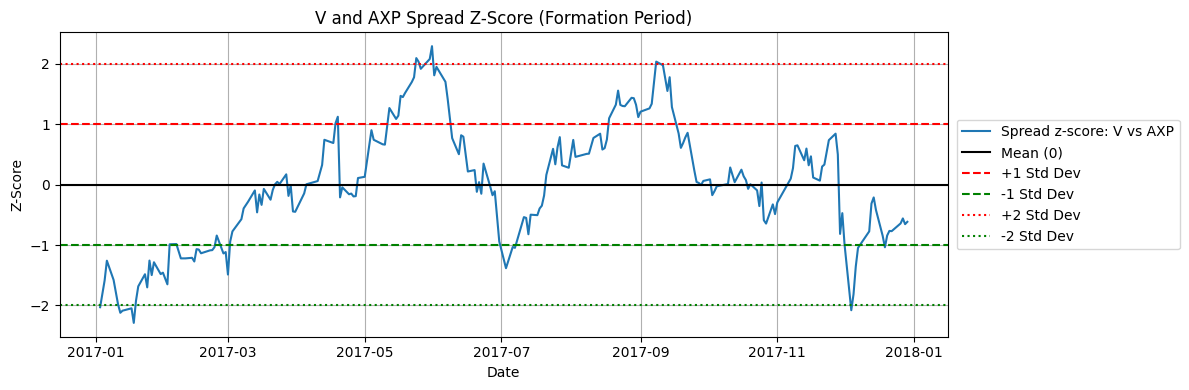

ADF p-value for spread (V, AXP): 0.0791
Spread is not stationary for V and AXP. 
We kick this pair out.


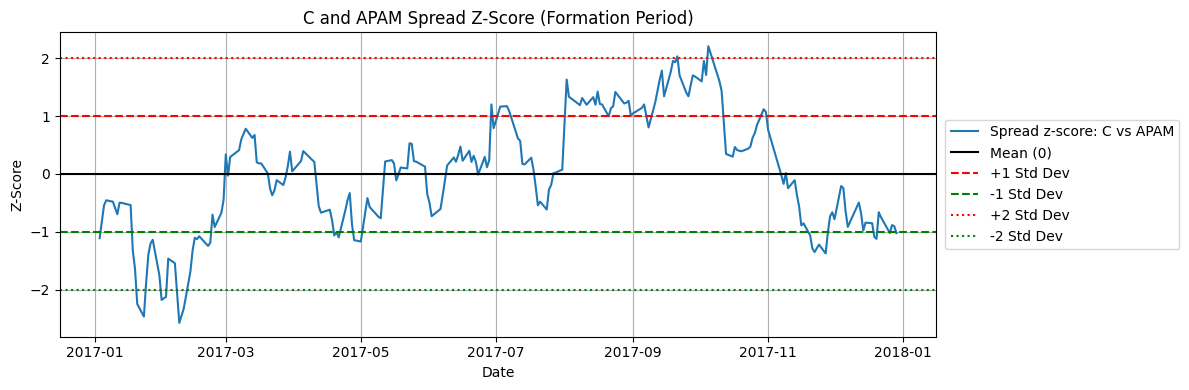

ADF p-value for spread (C, APAM): 0.1369
Spread is not stationary for C and APAM. 
We kick this pair out.


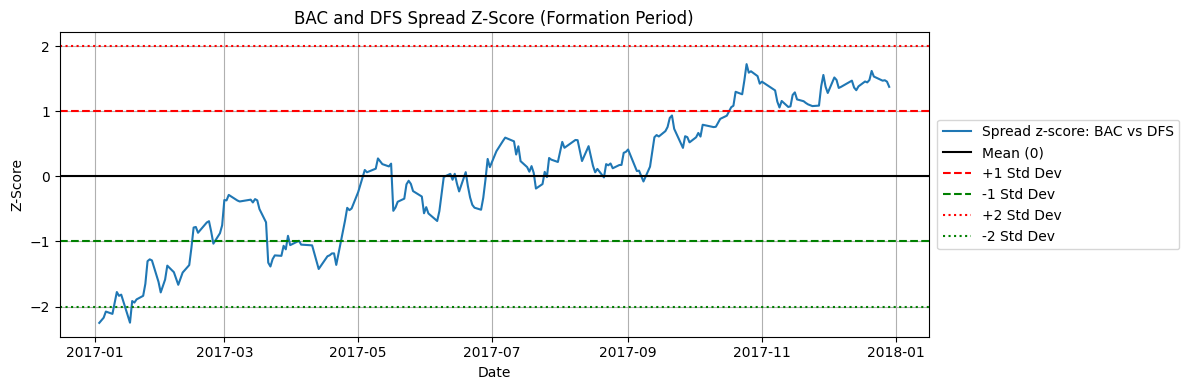

ADF p-value for spread (BAC, DFS): 0.3331
Spread is not stationary for BAC and DFS. 
We kick this pair out.


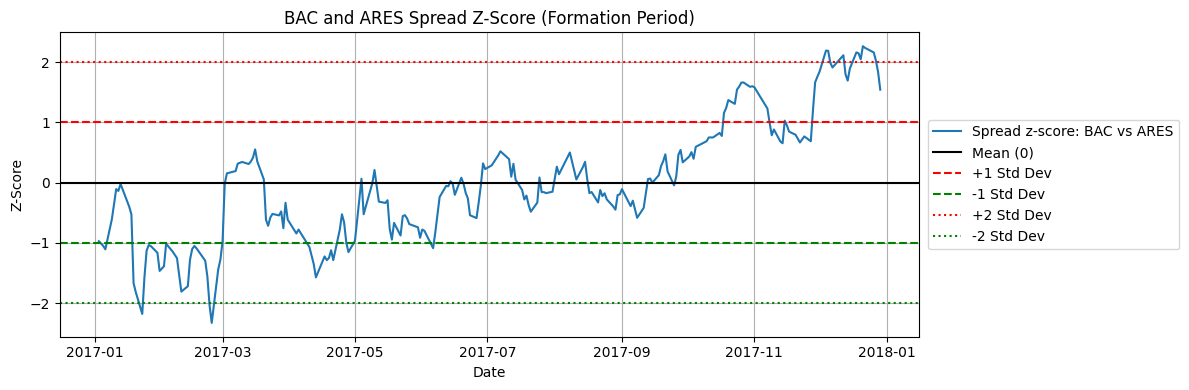

ADF p-value for spread (BAC, ARES): 0.3808
Spread is not stationary for BAC and ARES. 
We kick this pair out.


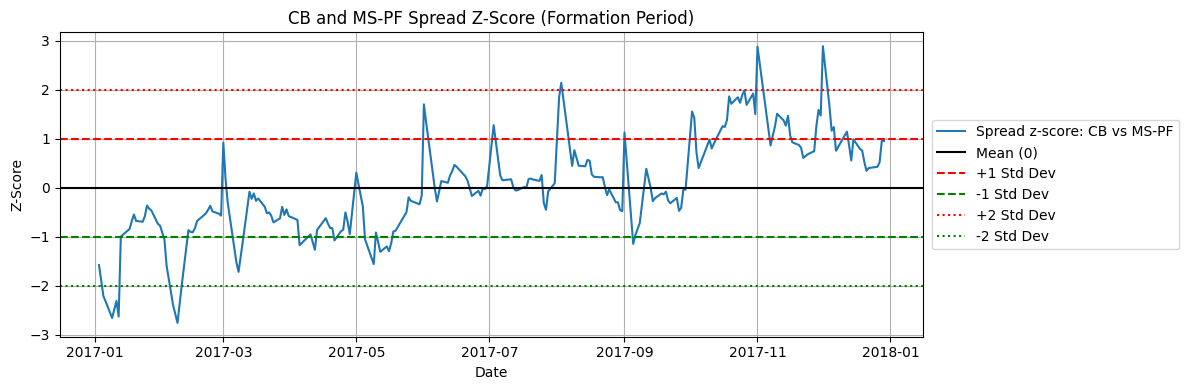

ADF p-value for spread (CB, MS-PF): 0.0225
Spread is stationary for CB and MS-PF.


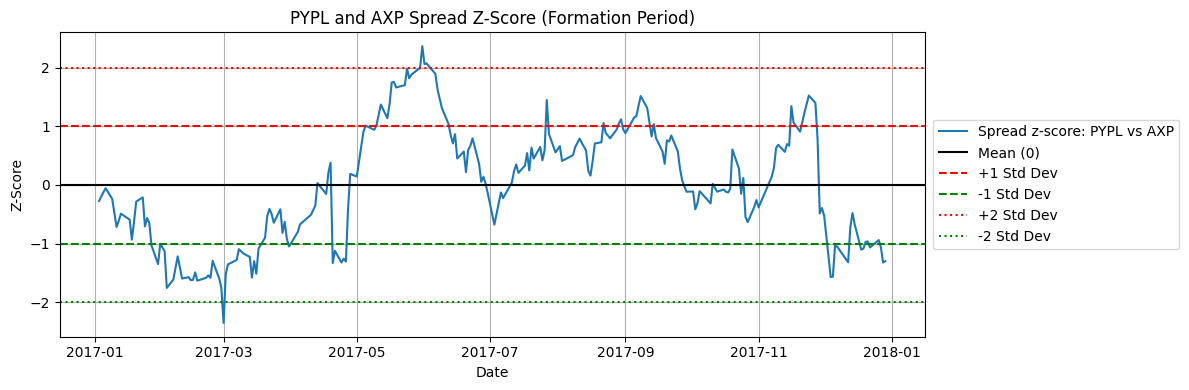

ADF p-value for spread (PYPL, AXP): 0.1932
Spread is not stationary for PYPL and AXP. 
We kick this pair out.


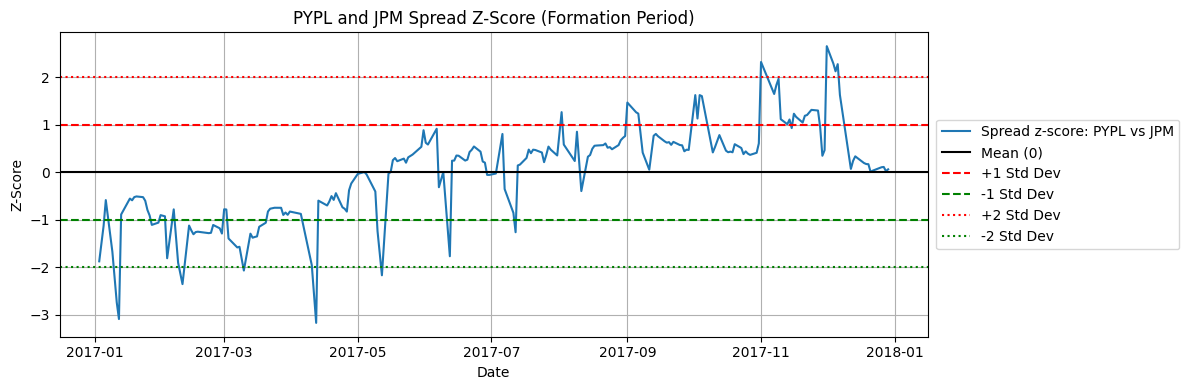

ADF p-value for spread (PYPL, JPM): 0.2106
Spread is not stationary for PYPL and JPM. 
We kick this pair out.


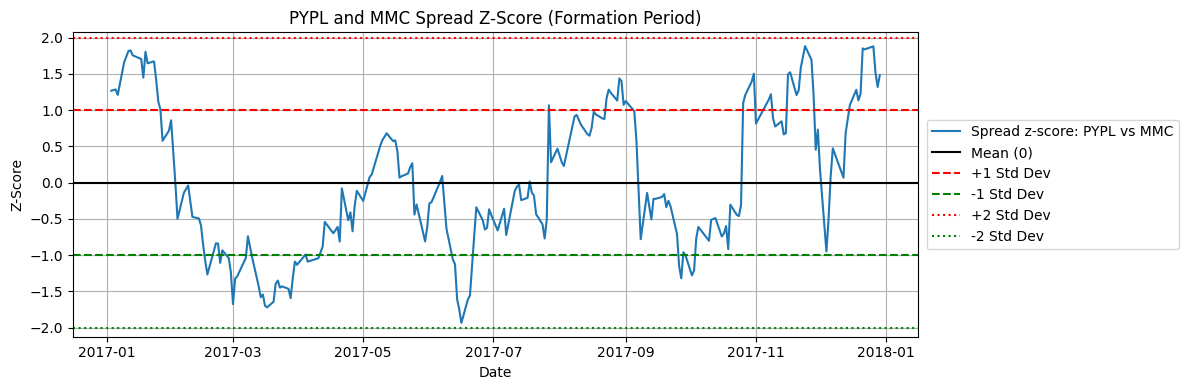

ADF p-value for spread (PYPL, MMC): 0.1143
Spread is not stationary for PYPL and MMC. 
We kick this pair out.


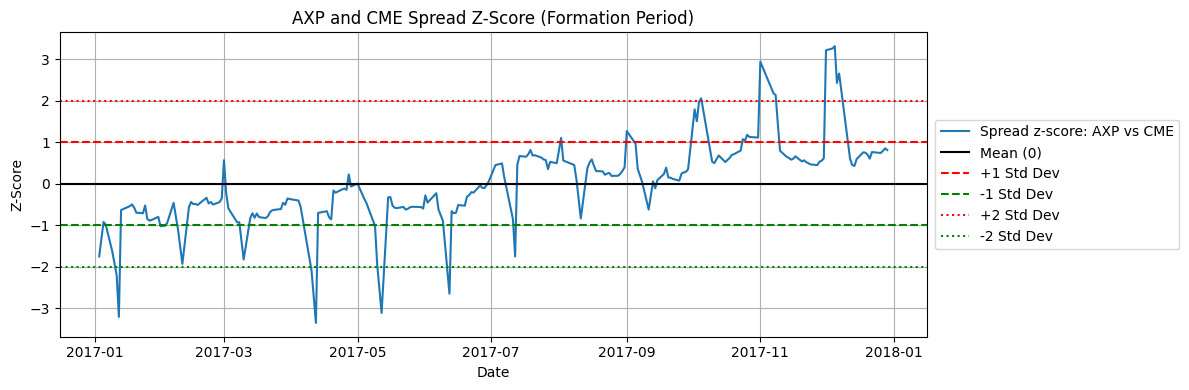

ADF p-value for spread (AXP, CME): 0.0000
Spread is stationary for AXP and CME.


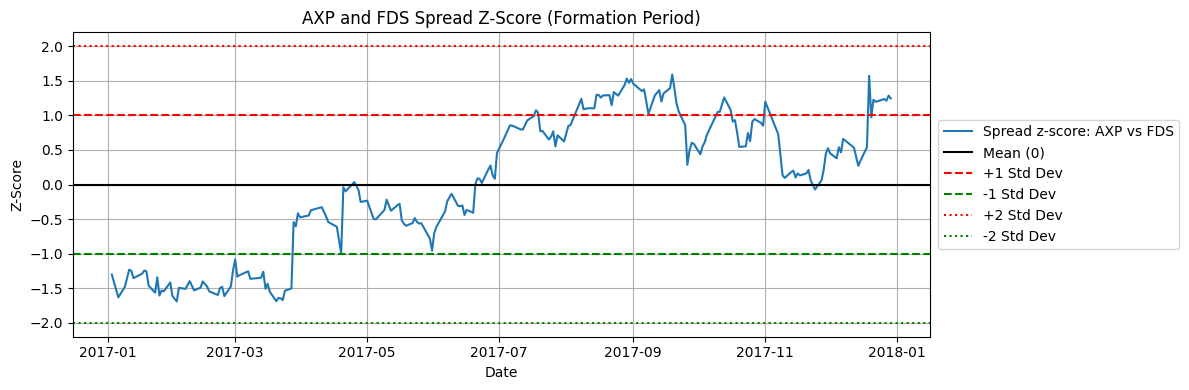

ADF p-value for spread (AXP, FDS): 0.5733
Spread is not stationary for AXP and FDS. 
We kick this pair out.


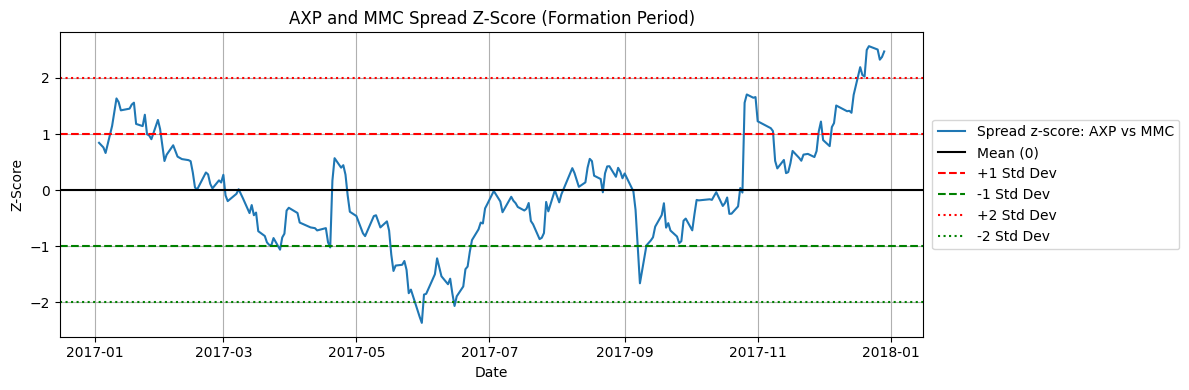

ADF p-value for spread (AXP, MMC): 0.6094
Spread is not stationary for AXP and MMC. 
We kick this pair out.


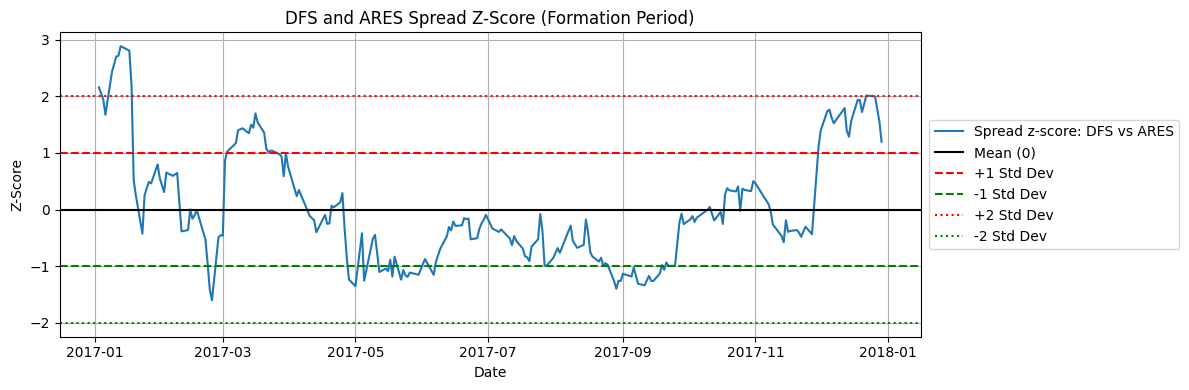

ADF p-value for spread (DFS, ARES): 0.0714
Spread is not stationary for DFS and ARES. 
We kick this pair out.


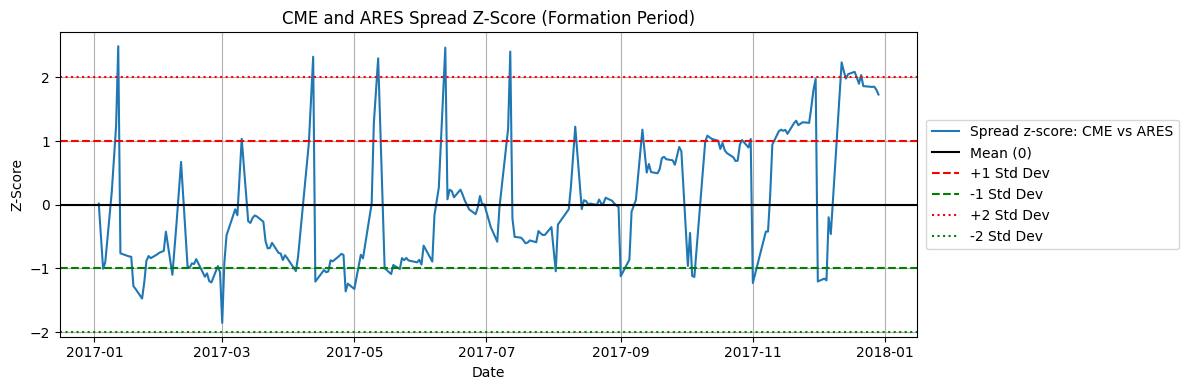

ADF p-value for spread (CME, ARES): 0.0000
Spread is stationary for CME and ARES.


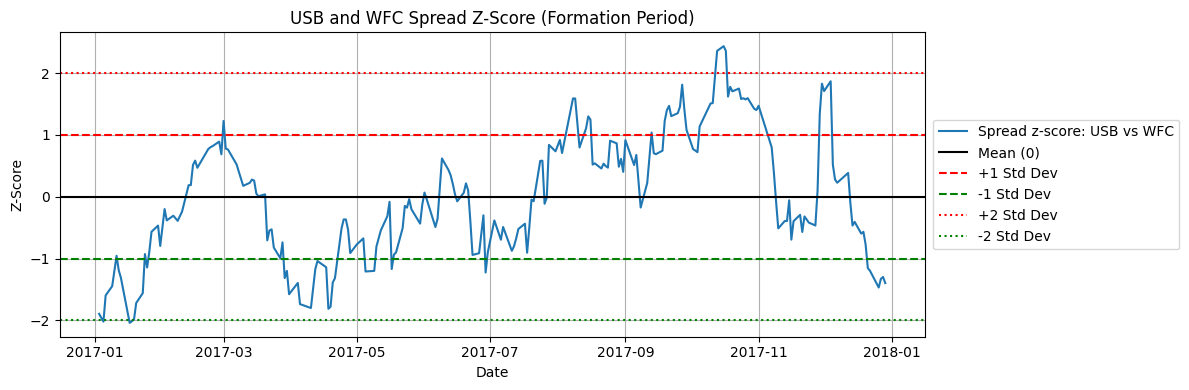

ADF p-value for spread (USB, WFC): 0.0468
Spread is stationary for USB and WFC.


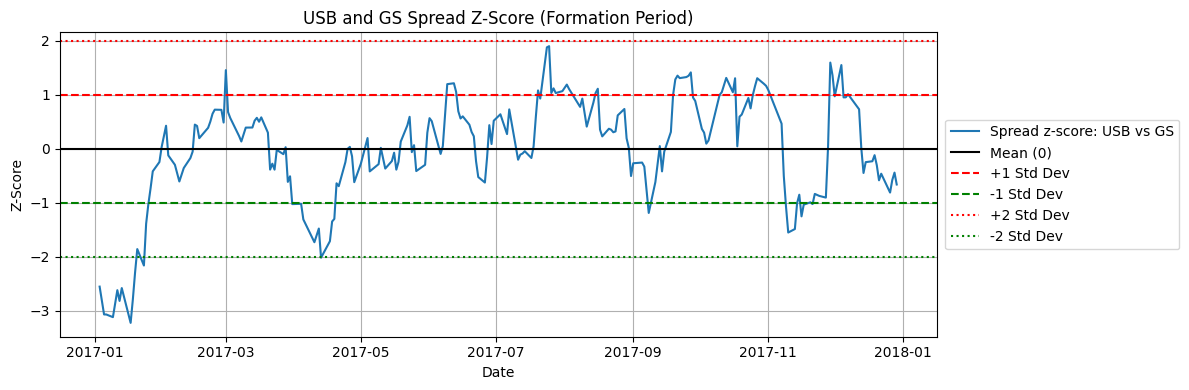

ADF p-value for spread (USB, GS): 0.0072
Spread is stationary for USB and GS.


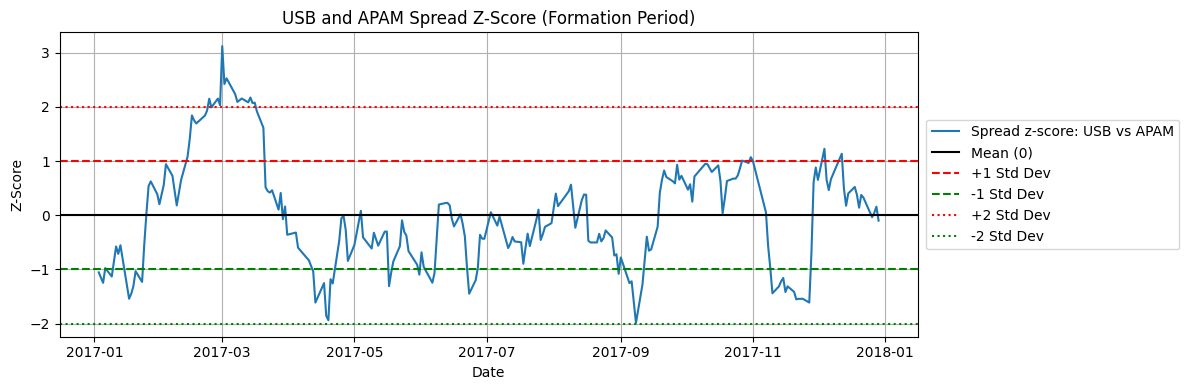

ADF p-value for spread (USB, APAM): 0.0399
Spread is stationary for USB and APAM.


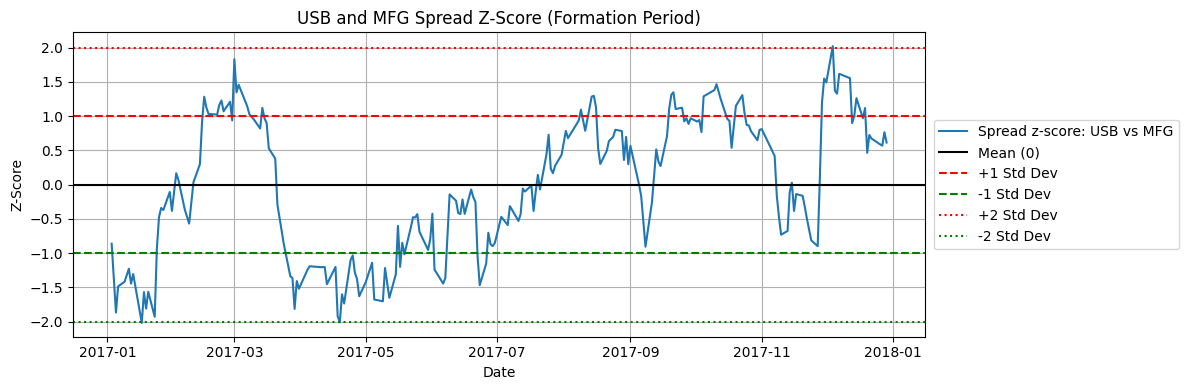

ADF p-value for spread (USB, MFG): 0.0752
Spread is not stationary for USB and MFG. 
We kick this pair out.


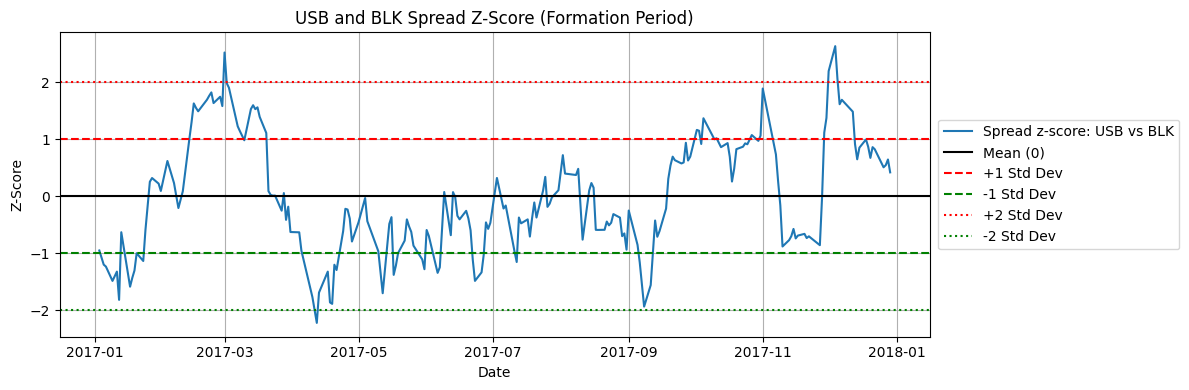

ADF p-value for spread (USB, BLK): 0.0154
Spread is stationary for USB and BLK.


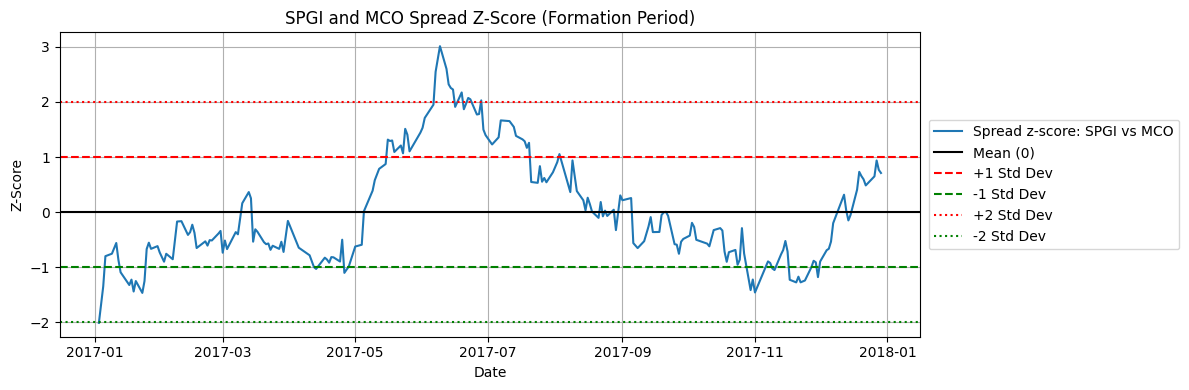

ADF p-value for spread (SPGI, MCO): 0.1306
Spread is not stationary for SPGI and MCO. 
We kick this pair out.


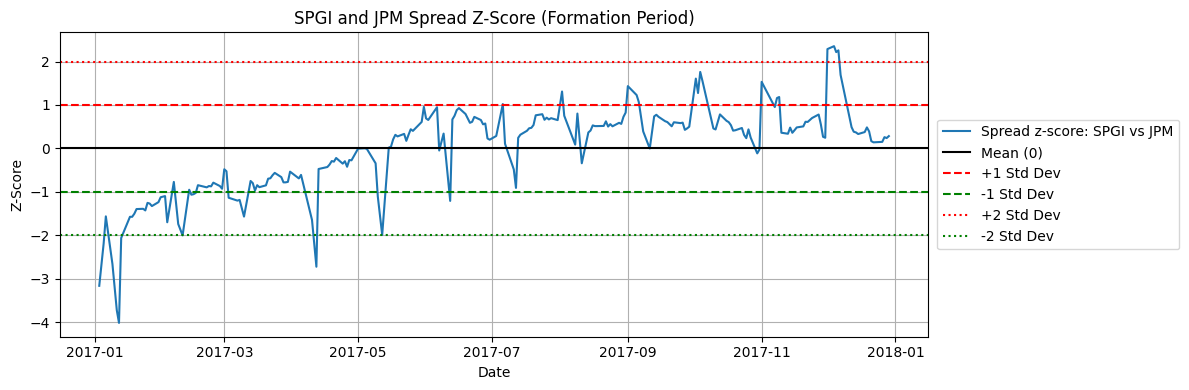

ADF p-value for spread (SPGI, JPM): 0.0014
Spread is stationary for SPGI and JPM.


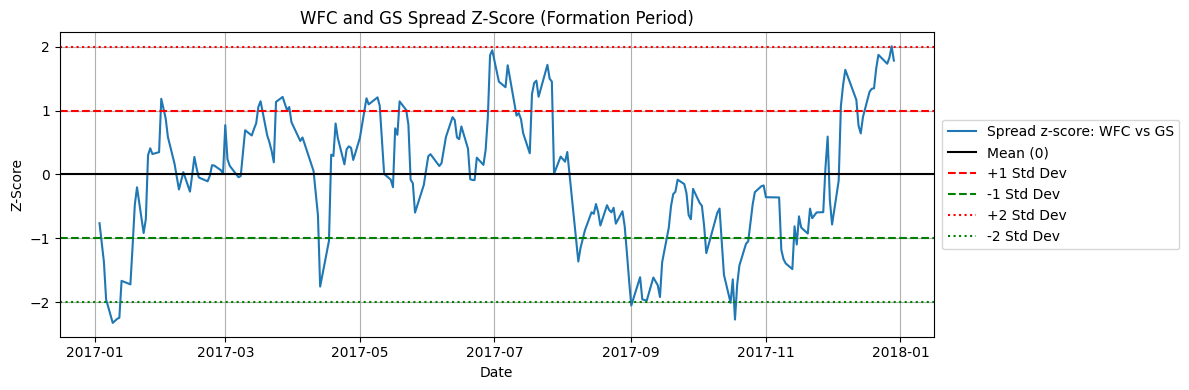

ADF p-value for spread (WFC, GS): 0.0092
Spread is stationary for WFC and GS.


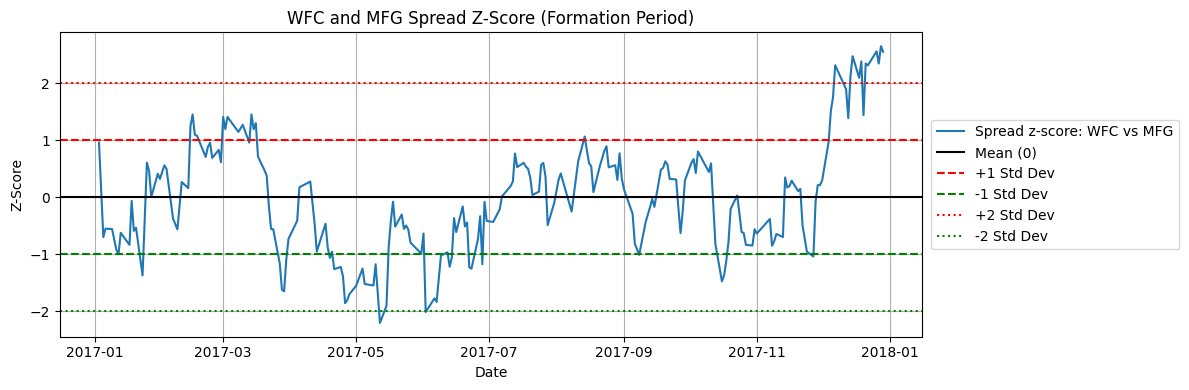

ADF p-value for spread (WFC, MFG): 0.0398
Spread is stationary for WFC and MFG.


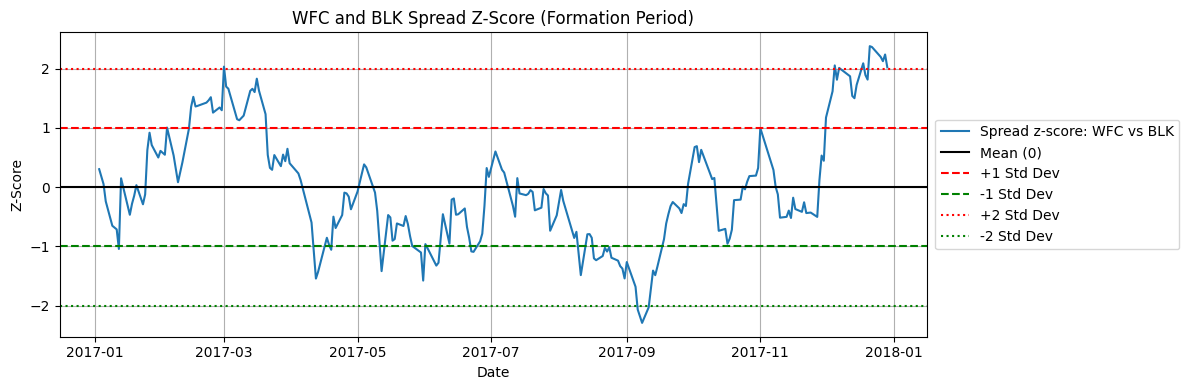

ADF p-value for spread (WFC, BLK): 0.2129
Spread is not stationary for WFC and BLK. 
We kick this pair out.


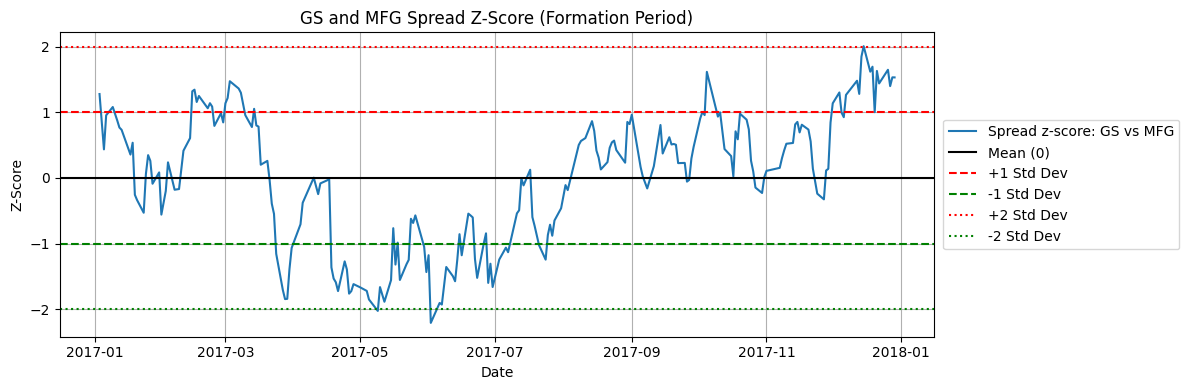

ADF p-value for spread (GS, MFG): 0.0850
Spread is not stationary for GS and MFG. 
We kick this pair out.


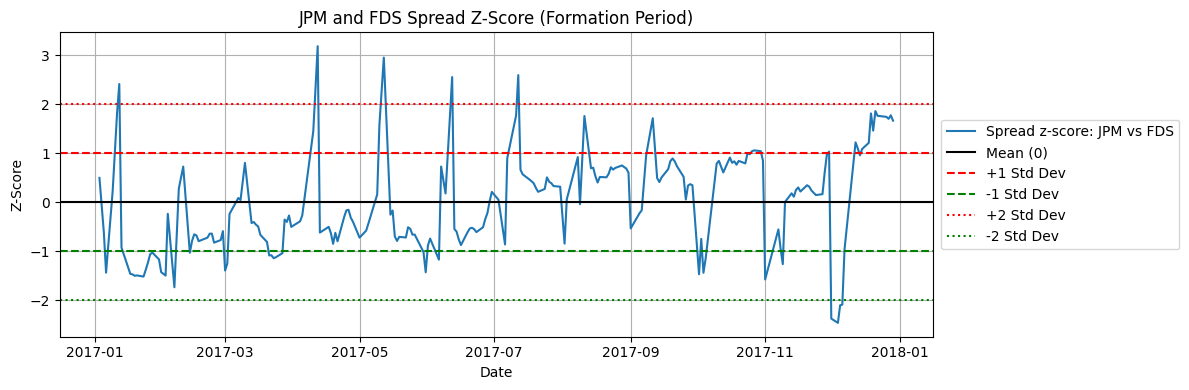

ADF p-value for spread (JPM, FDS): 0.0000
Spread is stationary for JPM and FDS.


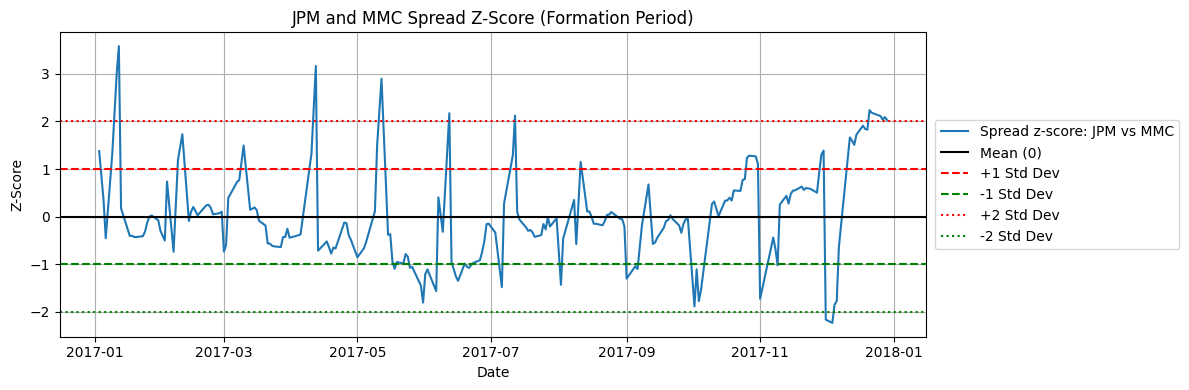

ADF p-value for spread (JPM, MMC): 0.0000
Spread is stationary for JPM and MMC.


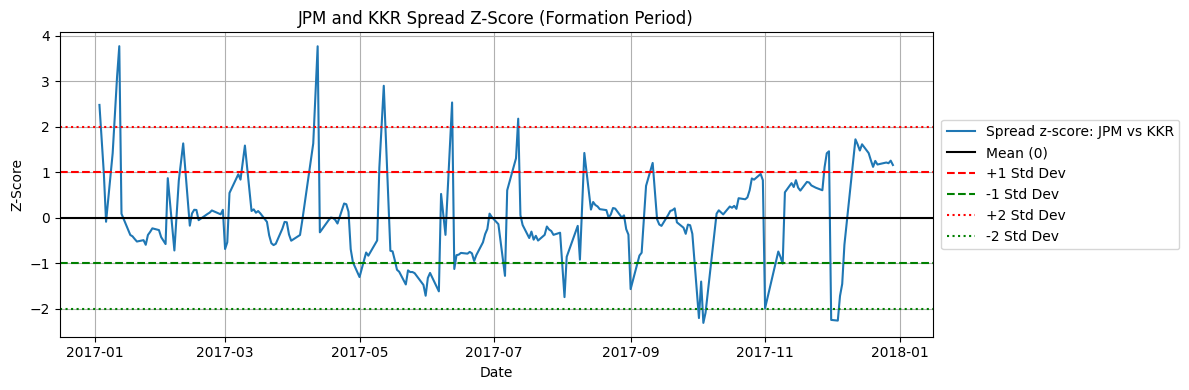

ADF p-value for spread (JPM, KKR): 0.0000
Spread is stationary for JPM and KKR.


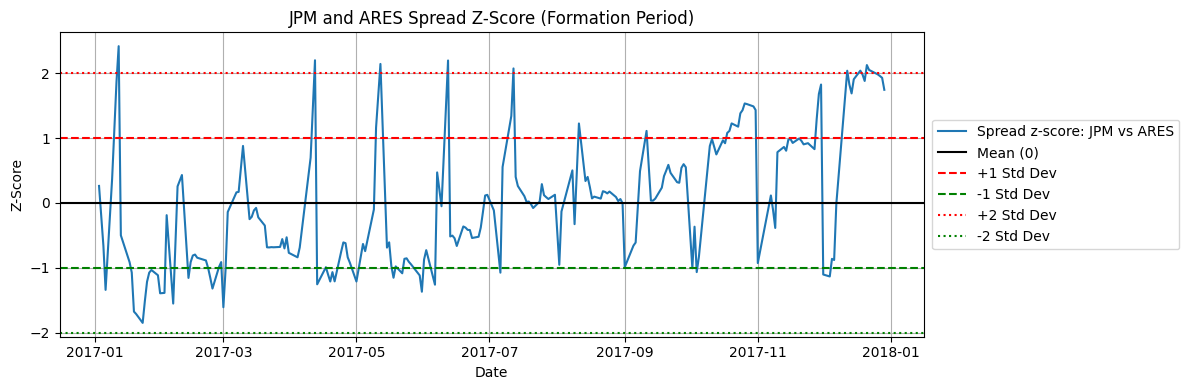

ADF p-value for spread (JPM, ARES): 0.0000
Spread is stationary for JPM and ARES.


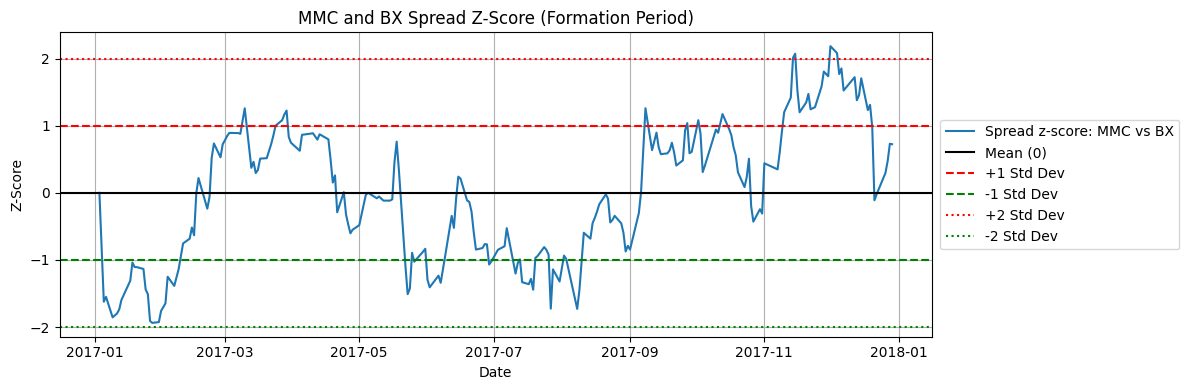

ADF p-value for spread (MMC, BX): 0.1255
Spread is not stationary for MMC and BX. 
We kick this pair out.


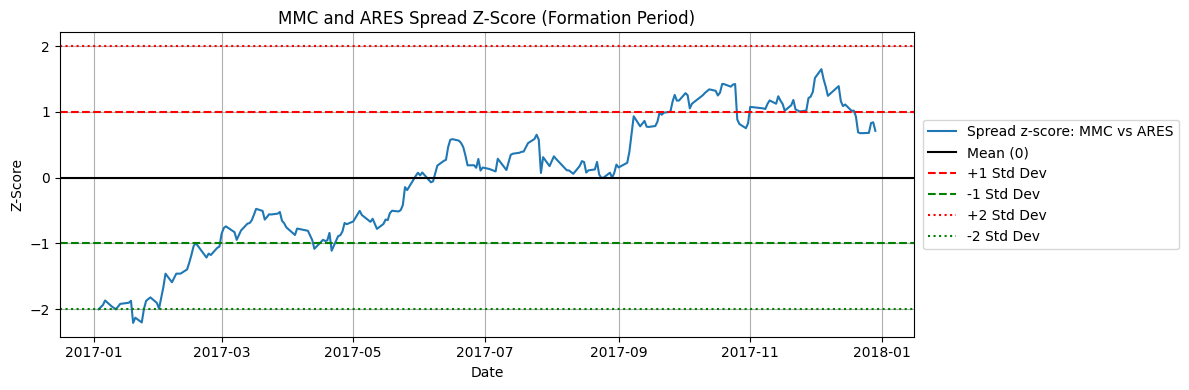

ADF p-value for spread (MMC, ARES): 0.3395
Spread is not stationary for MMC and ARES. 
We kick this pair out.


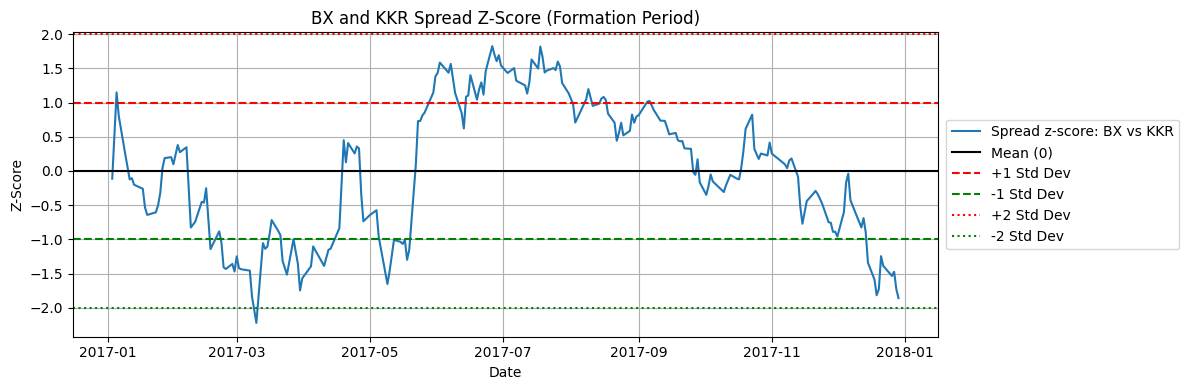

ADF p-value for spread (BX, KKR): 0.5513
Spread is not stationary for BX and KKR. 
We kick this pair out.


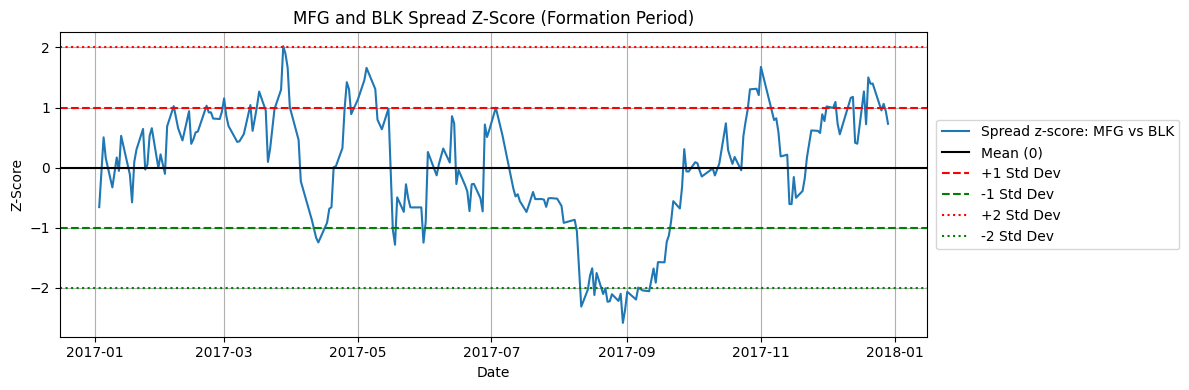

ADF p-value for spread (MFG, BLK): 0.0346
Spread is stationary for MFG and BLK.


In [7]:
# In-sample test: analyze the spread behavior for each cointegrated pair
for i in range(len(cointegrated_pairs)):
    s1 = cointegrated_pairs.loc[i, 's1']
    s2 = cointegrated_pairs.loc[i, 's2']
    
    # Use formation period data
    y = log_prices_form[s1]
    x = log_prices_form[s2]

    # Regress y on x
    model = sm.OLS(y, sm.add_constant(x)).fit()
    hedge_ratio = model.params[1]
    
    # Create spread
    spread = y - hedge_ratio * x
    zscore = (spread - spread.mean()) / spread.std()

    # Plot spread and z-score
    plt.figure(figsize=(12, 4))
    plt.plot(zscore, label=f'Spread z-score: {s1} vs {s2}')
    plt.axhline(0, color='black', label='Mean (0)')
    plt.axhline(1, color='red', linestyle='--', label='+1 Std Dev')
    plt.axhline(-1, color='green', linestyle='--', label='-1 Std Dev')
    plt.axhline(2, color='red', linestyle=':', label='+2 Std Dev')
    plt.axhline(-2, color='green', linestyle=':', label='-2 Std Dev')

    plt.title(f'{s1} and {s2} Spread Z-Score (Formation Period)')
    plt.xlabel("Date")
    plt.ylabel("Z-Score")
    plt.grid(True)

    # Legends
    plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), borderaxespad=0.)
    plt.tight_layout()
    plt.show()

    # Conduct ADF test on spread again: Do they mean-revert?
    adf_test = adfuller(spread)
    print(f"ADF p-value for spread ({s1}, {s2}): {adf_test[1]:.4f}")

    if adf_test[1] < 0.05:
        print(f"Spread is stationary for {s1} and {s2}.")
    else:
        cointegrated_pairs = cointegrated_pairs.drop(i)
        print(f"Spread is not stationary for {s1} and {s2}. \nWe kick this pair out.")


In [8]:
# Final cointegrated pairs
cointegrated_pairs.reset_index(drop=True, inplace=True)
display(cointegrated_pairs)

,s1,s2,result
0,CB,MS-PF,True
1,AXP,CME,True
2,CME,ARES,True
3,USB,WFC,True
4,USB,GS,True
5,USB,APAM,True
6,USB,BLK,True
7,SPGI,JPM,True
8,WFC,GS,True
9,WFC,MFG,True


## Trading Period (Actual Trading)

In [9]:
def buy_and_hold_portfolio(s1, s2, returns_trade):
    """
    Builds a buy-and-hold portfolio for s1 and s2 with 50/50 allocation.
    """
    # Equal weights
    weights = 0.5

    # Portfolio returns
    bnh_returns = weights * returns_trade[s1] + weights * returns_trade[s2]
    cumret_bnh = (bnh_returns + 1).cumprod()

    return bnh_returns, cumret_bnh

def calculate_metrics(cumret_series):
    rets = cumret_series.pct_change().dropna()
    total_return = cumret_series[-1] / cumret_series[0] - 1
    apr = (1 + total_return) ** (252 / len(rets)) - 1
    sharpe = np.sqrt(252) * np.nanmean(rets) / np.nanstd(rets)
    return total_return, apr, sharpe

def calculate_metrics_add(ret):
    '''
    Calculate additional performance metrics from daily returns.
    '''
    best_day = np.max(ret)
    worst_day = np.min(ret)
    pct_days_up = len(ret[ret > 0]) / len(ret)
    pct_days_down = len(ret[ret < 0]) / len(ret)
    avg_daily_gain = np.mean(ret[ret > 0]) if len(ret[ret > 0]) > 0 else 0
    sd_pos_ret = np.std(ret[ret > 0]) if len(ret[ret > 0]) > 0 else 0
    avg_daily_loss = np.mean(ret[ret < 0]) if len(ret[ret < 0]) > 0 else 0
    sd_neg_ret = np.std(ret[ret < 0]) if len(ret[ret < 0]) > 0 else 0

    return {
        'Best day': best_day,
        'Worst day': worst_day,
        '% days up': pct_days_up,
        '% days down': pct_days_down,
        'Avg gain': avg_daily_gain,
        'Std gain': sd_pos_ret,
        'Avg loss': avg_daily_loss,
        'Std loss': sd_neg_ret
    }

def map_position(val, is_s2=False, hedge_ratio=1.0):
    """
    Convert 2/1/NaN 'trade' signals into -1/0/+1 signals.
    For s1: 2 => short => -1, 1 => long => +1, NaN => 0
    For s2: multiply by hedge_ratio, and flip sign for short.
    """
    if pd.isna(val):
        return 0
    elif val == 2:   # short
        return -hedge_ratio if is_s2 else -1
    elif val == 1:   # long
        return +hedge_ratio if is_s2 else +1
    else:
        return 0

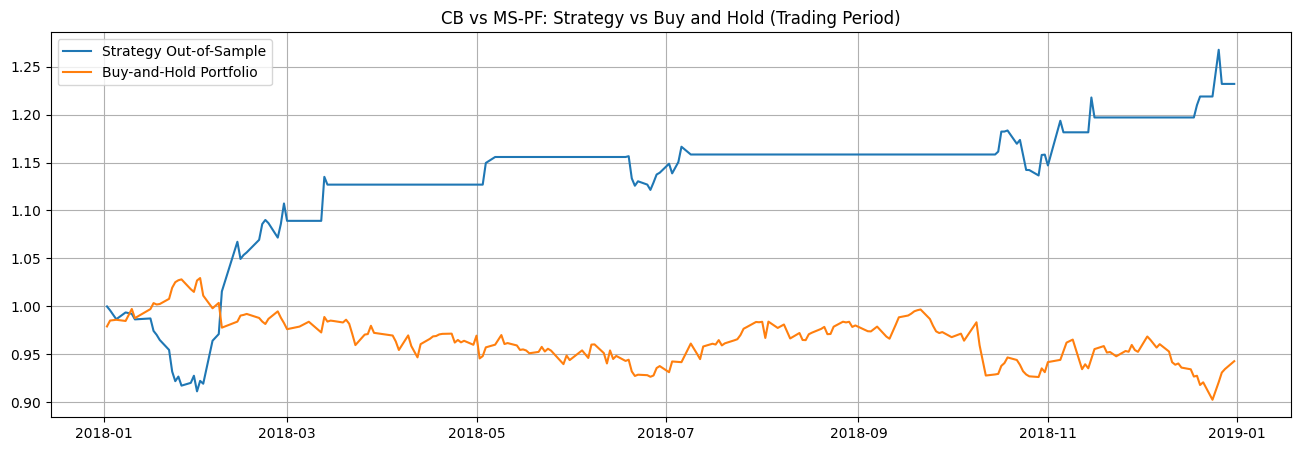

,CB-MS-PF Algorithm,CB-MS-PF Buy and Hold,CB Indiv Stock,MS-PF Indiv Stock
Best day,0.050914,0.020596,0.040270,0.041177
Worst day,-0.028061,-0.032866,-0.048332,-0.033565
% days up,0.176991,0.548673,0.500000,0.460177
% days down,0.146018,0.451327,0.500000,0.495575
Avg gain,0.013864,0.005620,0.008907,0.007495
Std gain,0.014543,0.004867,0.007238,0.008965
Avg loss,-0.010173,-0.007327,-0.009648,-0.007112
Std loss,0.006419,0.006486,0.009223,0.007789
Total Return,0.231915,-0.036985,-0.072017,-0.014705
APR,0.263136,-0.041330,-0.080302,-0.016456


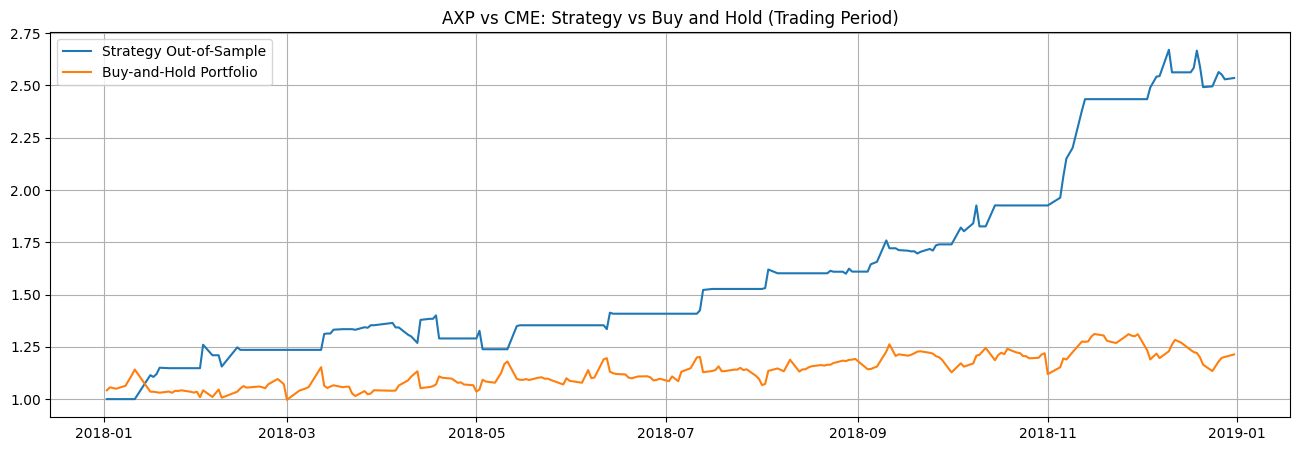

,AXP-CME Algorithm,AXP-CME Buy and Hold,AXP Indiv Stock,CME Indiv Stock
Best day,0.114477,0.089863,0.075880,0.168546
Worst day,-0.078757,-0.092827,-0.056297,-0.181782
% days up,0.234513,0.539823,0.513274,0.544248
% days down,0.154867,0.460177,0.486726,0.451327
Avg gain,0.029830,0.016824,0.010794,0.028403
Std gain,0.029272,0.017111,0.011384,0.033900
Avg loss,-0.016981,-0.017178,-0.011363,-0.029055
Std loss,0.019707,0.020323,0.011584,0.040472
Total Return,1.535128,0.164591,-0.022560,0.214512
APR,1.834522,0.186081,-0.025233,0.243169


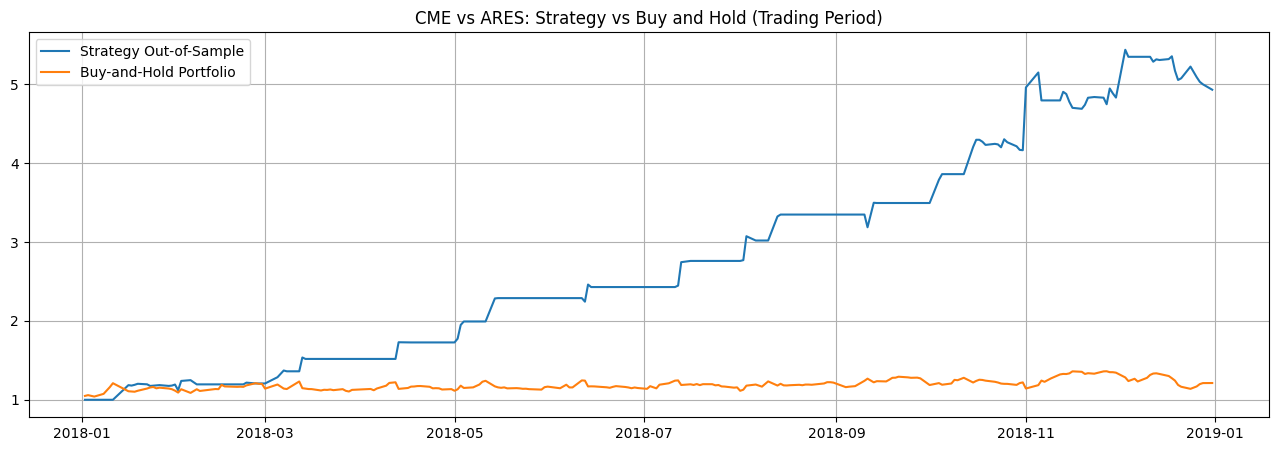

,CME-ARES Algorithm,CME-ARES Buy and Hold,CME Indiv Stock,ARES Indiv Stock
Best day,0.191169,0.084273,0.168546,0.077092
Worst day,-0.068742,-0.084355,-0.181782,-0.116832
% days up,0.212389,0.495575,0.544248,0.469027
% days down,0.181416,0.504425,0.451327,0.500000
Avg gain,0.048910,0.018963,0.028403,0.016836
Std gain,0.053725,0.017611,0.033900,0.013475
Avg loss,-0.015262,-0.016316,-0.029055,-0.015813
Std loss,0.015219,0.018041,0.040472,0.016471
Total Return,3.930885,0.155738,0.214512,-0.064724
APR,4.971396,0.175987,0.243169,-0.072204


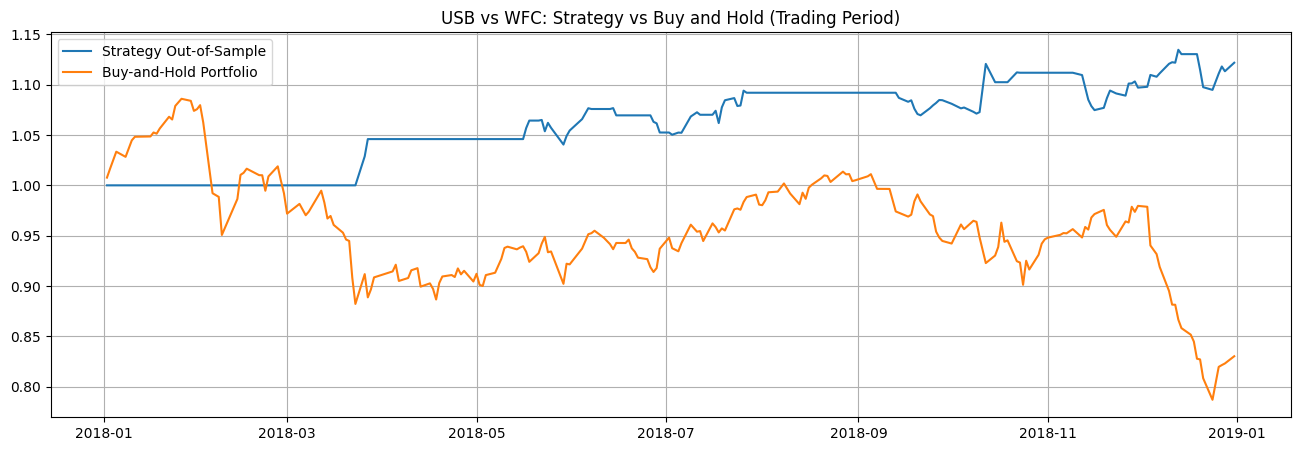

,USB-WFC Algorithm,USB-WFC Buy and Hold,USB Indiv Stock,WFC Indiv Stock
Best day,0.044621,0.041446,0.041421,0.046931
Worst day,-0.016199,-0.066157,-0.047628,-0.092243
% days up,0.194690,0.500000,0.495575,0.486726
% days down,0.185841,0.500000,0.500000,0.504425
Avg gain,0.007623,0.008805,0.008908,0.010388
Std gain,0.008033,0.007905,0.007577,0.009396
Avg loss,-0.005165,-0.010272,-0.009836,-0.011935
Std loss,0.004500,0.010308,0.009415,0.012599
Total Return,0.121694,-0.175935,-0.130906,-0.223666
APR,0.137259,-0.194850,-0.145416,-0.246897


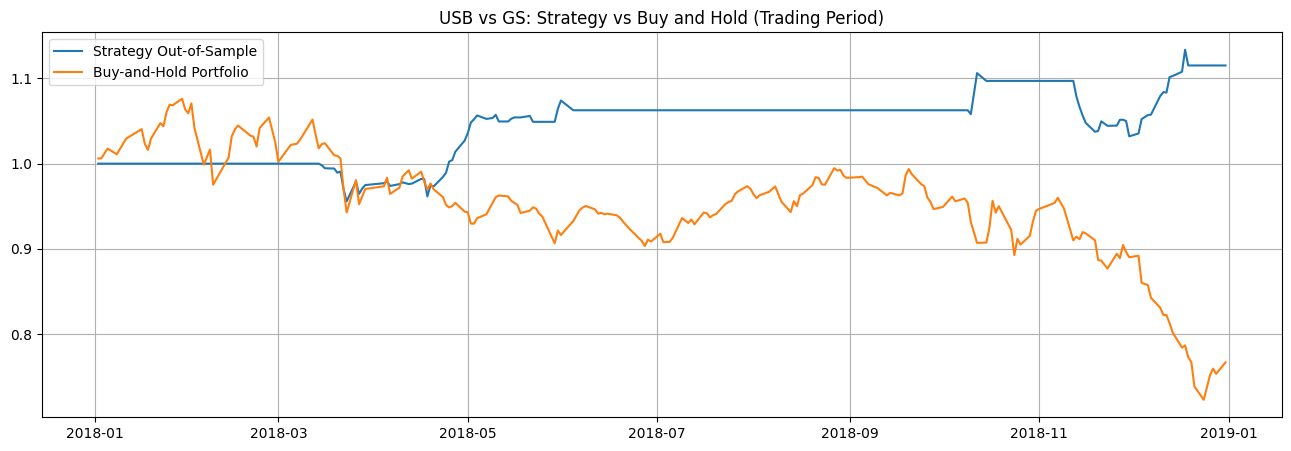

,USB-GS Algorithm,USB-GS Buy and Hold,USB Indiv Stock,GS Indiv Stock
Best day,0.045545,0.040322,0.041421,0.042085
Worst day,-0.020652,-0.041051,-0.047628,-0.074556
% days up,0.194690,0.469027,0.495575,0.446903
% days down,0.123894,0.530973,0.500000,0.553097
Avg gain,0.007758,0.009696,0.008908,0.012428
Std gain,0.008573,0.008339,0.007577,0.009777
Avg loss,-0.008140,-0.010603,-0.009836,-0.013045
Std loss,0.006192,0.009696,0.009415,0.012255
Total Return,0.115244,-0.237906,-0.130906,-0.337619
APR,0.129937,-0.262351,-0.145416,-0.369564


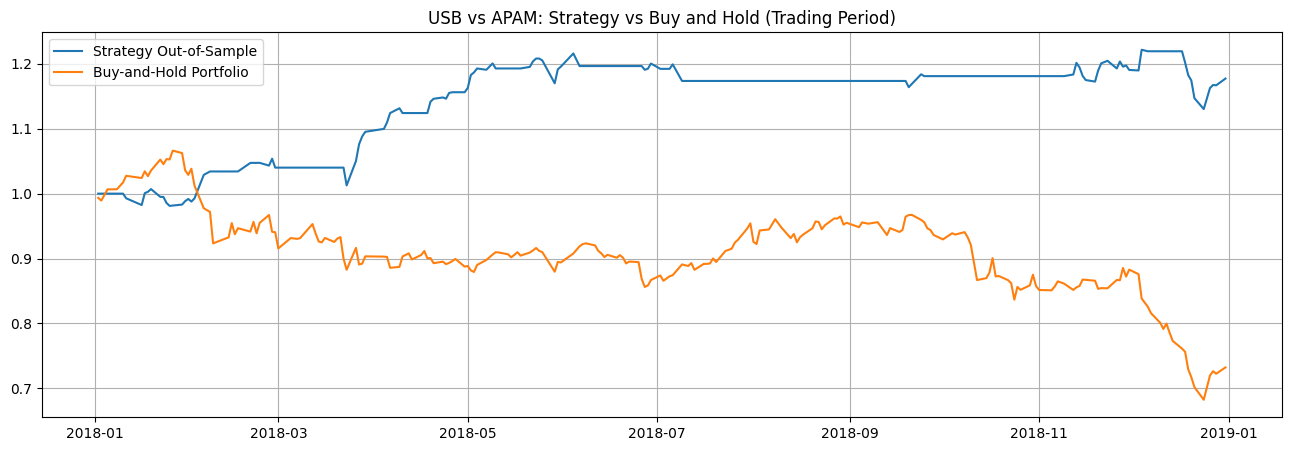

,USB-APAM Algorithm,USB-APAM Buy and Hold,USB Indiv Stock,APAM Indiv Stock
Best day,0.037213,0.054727,0.041421,0.072206
Worst day,-0.029253,-0.058780,-0.047628,-0.069932
% days up,0.234513,0.491150,0.495575,0.460177
% days down,0.163717,0.504425,0.500000,0.517699
Avg gain,0.009303,0.009398,0.008908,0.013078
Std gain,0.008609,0.008106,0.007577,0.010330
Avg loss,-0.008735,-0.011679,-0.009836,-0.015581
Std loss,0.007211,0.011062,0.009415,0.014035
Total Return,0.177378,-0.263015,-0.130906,-0.382251
APR,0.200676,-0.289517,-0.145416,-0.416945


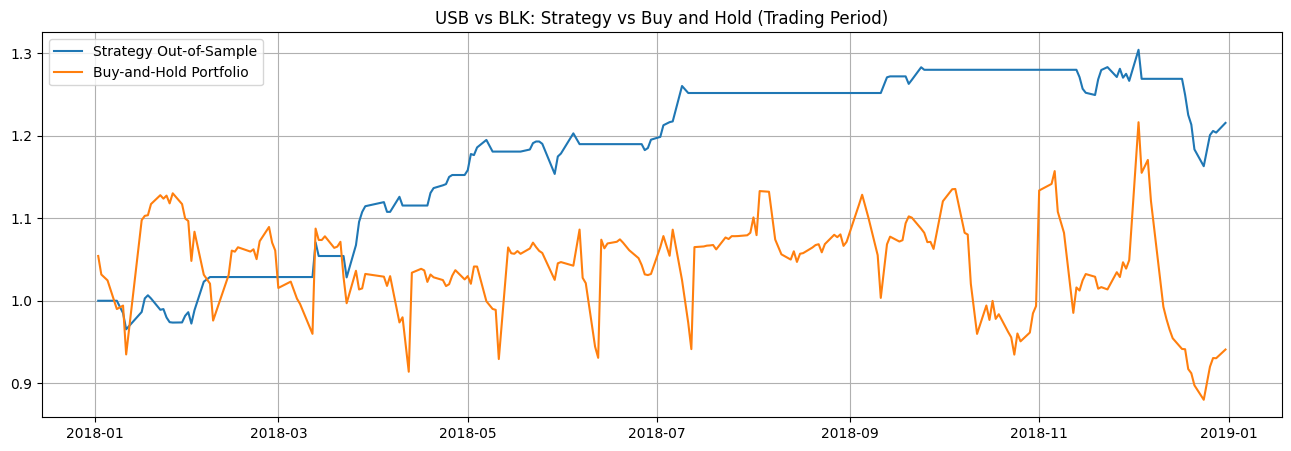

,USB-BLK Algorithm,USB-BLK Buy and Hold,USB Indiv Stock,BLK Indiv Stock
Best day,0.040867,0.174269,0.041421,0.339893
Worst day,-0.030692,-0.089713,-0.047628,-0.175098
% days up,0.234513,0.460177,0.495575,0.446903
% days down,0.154867,0.539823,0.500000,0.553097
Avg gain,0.011144,0.023661,0.008908,0.043703
Std gain,0.010588,0.038289,0.007577,0.078913
Avg loss,-0.011026,-0.019468,-0.009836,-0.033031
Std loss,0.007635,0.020121,0.009415,0.039426
Total Return,0.215746,-0.107637,-0.130906,-0.287416
APR,0.244584,-0.119749,-0.145416,-0.315810


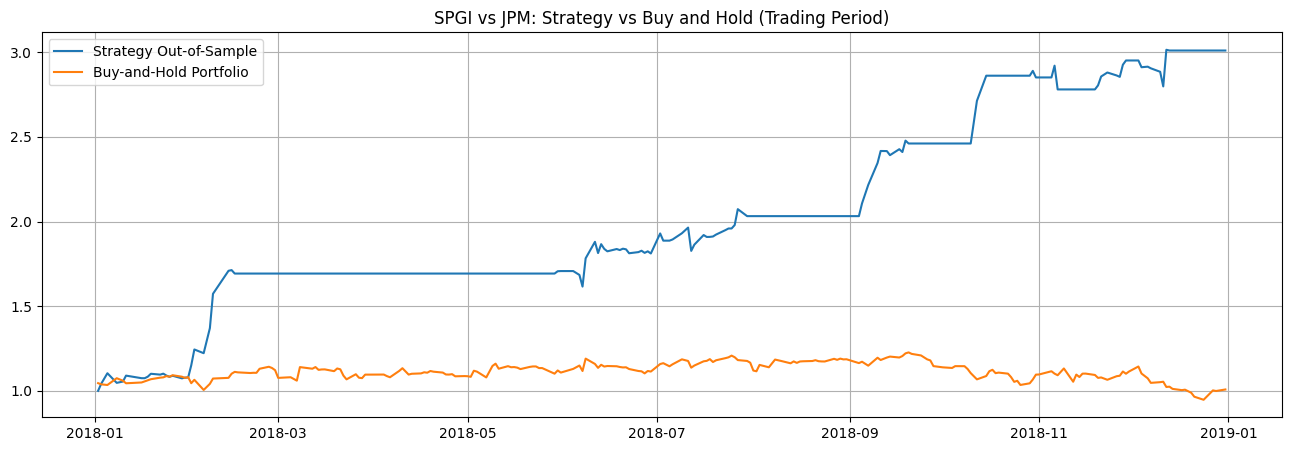

,SPGI-JPM Algorithm,SPGI-JPM Buy and Hold,SPGI Indiv Stock,JPM Indiv Stock
Best day,0.148058,0.075502,0.098161,0.136244
Worst day,-0.070062,-0.069262,-0.061862,-0.116727
% days up,0.247788,0.486726,0.522124,0.451327
% days down,0.163717,0.513274,0.473451,0.539823
Avg gain,0.030510,0.014309,0.010895,0.024373
Std gain,0.033875,0.014627,0.012096,0.028803
Avg loss,-0.014670,-0.013147,-0.011612,-0.019929
Std loss,0.015653,0.011828,0.011278,0.021439
Total Return,2.010430,-0.035858,0.021456,-0.150004
APR,2.436085,-0.040074,0.024061,-0.166421


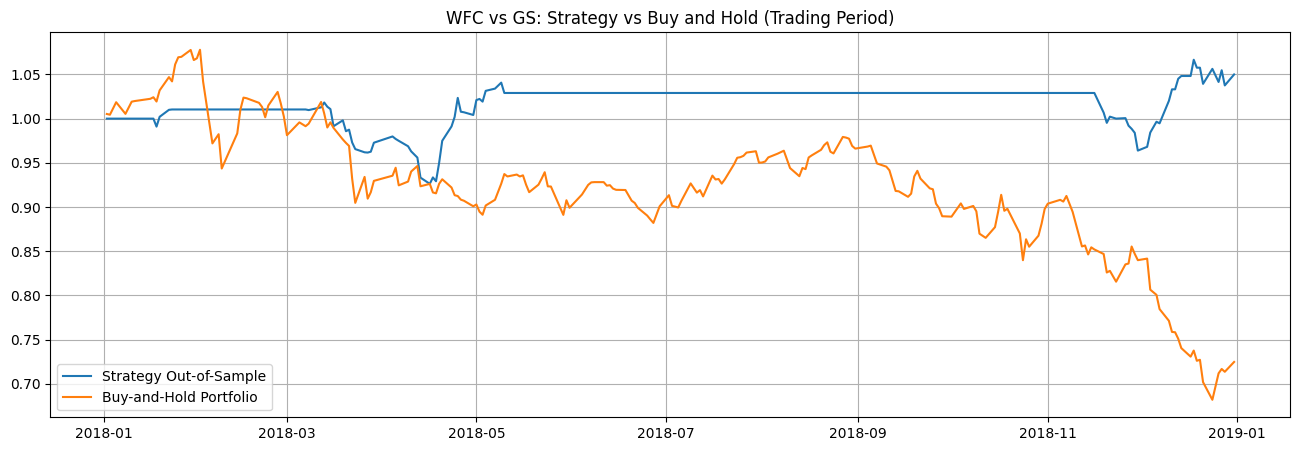

,WFC-GS Algorithm,WFC-GS Buy and Hold,WFC Indiv Stock,GS Indiv Stock
Best day,0.026320,0.043864,0.046931,0.042085
Worst day,-0.023729,-0.067137,-0.092243,-0.074556
% days up,0.150442,0.477876,0.486726,0.446903
% days down,0.159292,0.522124,0.504425,0.553097
Avg gain,0.010368,0.010053,0.010388,0.012428
Std gain,0.007097,0.008648,0.009396,0.009777
Avg loss,-0.008306,-0.011715,-0.011935,-0.013045
Std loss,0.006594,0.011258,0.012599,0.012255
Total Return,0.049990,-0.279064,-0.223666,-0.337619
APR,0.056154,-0.306822,-0.246897,-0.369564


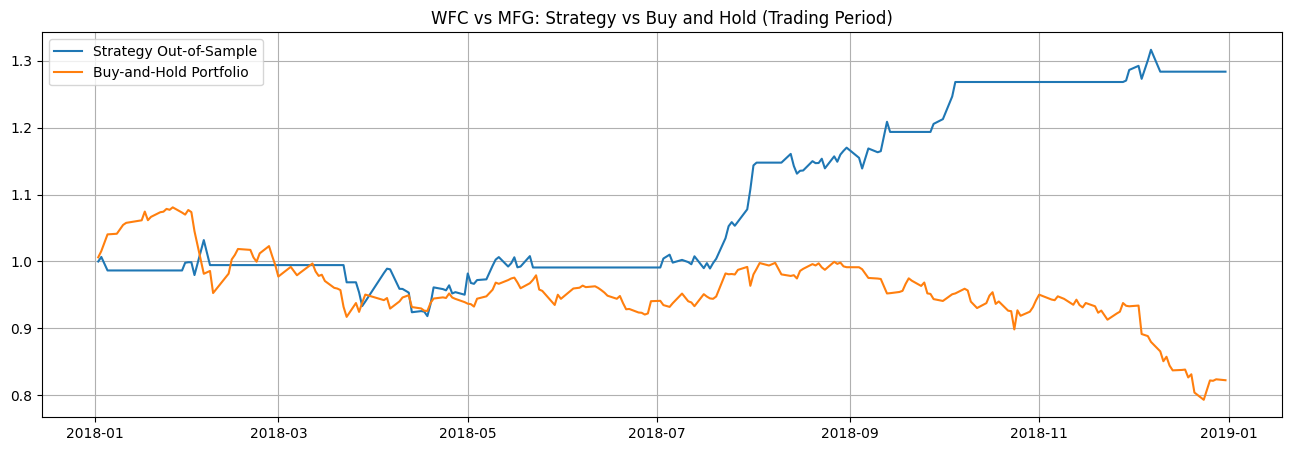

,WFC-MFG Algorithm,WFC-MFG Buy and Hold,WFC Indiv Stock,MFG Indiv Stock
Best day,0.053305,0.036380,0.046931,0.044379
Worst day,-0.036190,-0.060827,-0.092243,-0.045603
% days up,0.265487,0.473451,0.486726,0.424779
% days down,0.172566,0.526549,0.504425,0.460177
Avg gain,0.012319,0.008274,0.010388,0.009729
Std gain,0.011587,0.007316,0.009396,0.007457
Avg loss,-0.012222,-0.008939,-0.011935,-0.010315
Std loss,0.008931,0.009480,0.012599,0.008984
Total Return,0.283442,-0.182355,-0.223666,-0.148961
APR,0.322457,-0.201872,-0.246897,-0.165275


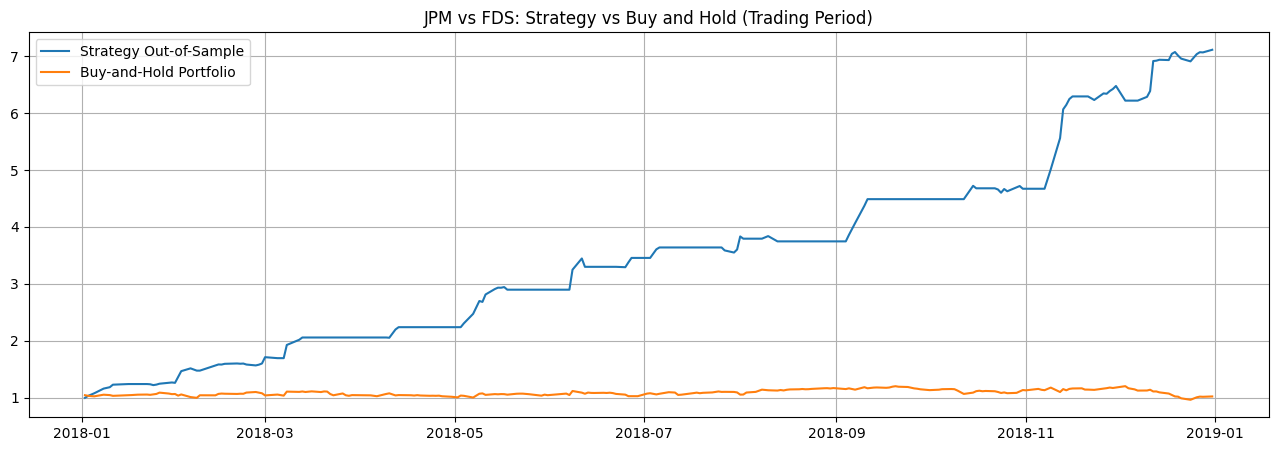

,JPM-FDS Algorithm,JPM-FDS Buy and Hold,JPM Indiv Stock,FDS Indiv Stock
Best day,0.136454,0.067906,0.136244,0.047781
Worst day,-0.042526,-0.066142,-0.116727,-0.051715
% days up,0.309735,0.495575,0.451327,0.539823
% days down,0.141593,0.504425,0.539823,0.460177
Avg gain,0.033774,0.013709,0.024373,0.009878
Std gain,0.032056,0.014596,0.028803,0.009311
Avg loss,-0.010235,-0.012913,-0.019929,-0.010894
Std loss,0.010023,0.011556,0.021439,0.010398
Total Return,6.109289,-0.021020,-0.150004,0.056393
APR,7.995914,-0.023512,-0.166421,0.063371


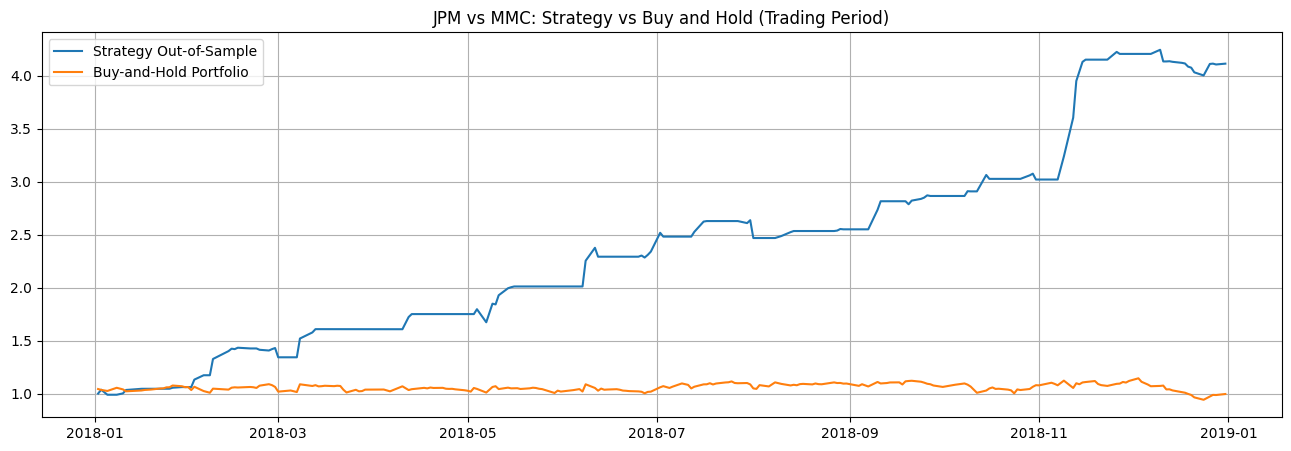

,JPM-MMC Algorithm,JPM-MMC Buy and Hold,JPM Indiv Stock,MMC Indiv Stock
Best day,0.131957,0.071941,0.136244,0.058824
Worst day,-0.068659,-0.061725,-0.116727,-0.040055
% days up,0.278761,0.500000,0.451327,0.526549
% days down,0.132743,0.500000,0.539823,0.473451
Avg gain,0.030585,0.013662,0.024373,0.008526
Std gain,0.034484,0.014114,0.028803,0.007640
Avg loss,-0.014656,-0.013354,-0.019929,-0.009343
Std loss,0.019523,0.011187,0.021439,0.008403
Total Return,3.115960,-0.045205,-0.150004,0.010873
APR,3.877616,-0.050490,-0.166421,0.012186


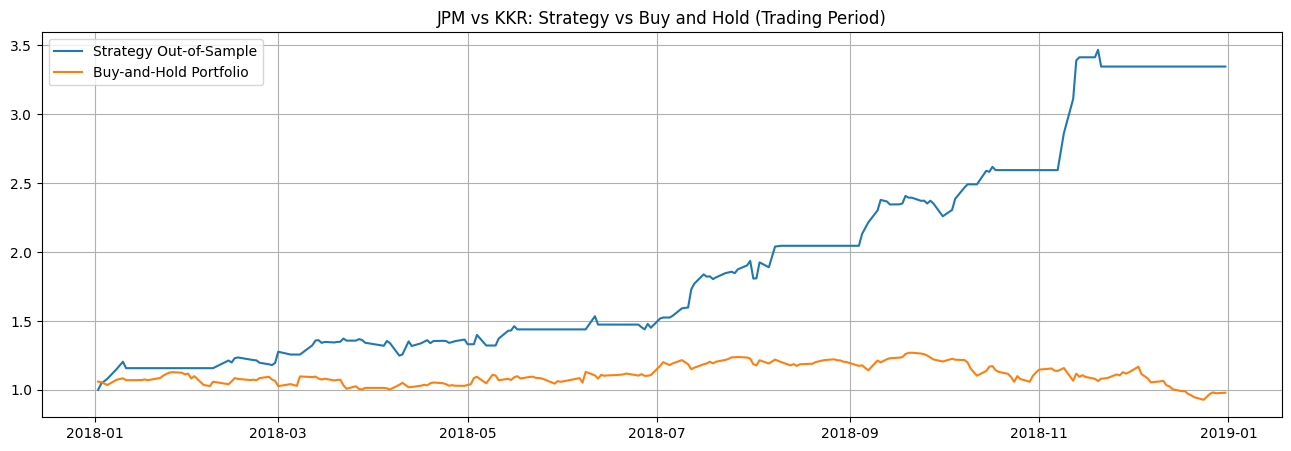

,JPM-KKR Algorithm,JPM-KKR Buy and Hold,JPM Indiv Stock,KKR Indiv Stock
Best day,0.103351,0.073873,0.136244,0.062839
Worst day,-0.067550,-0.078961,-0.116727,-0.065588
% days up,0.331858,0.513274,0.451327,0.526549
% days down,0.194690,0.486726,0.539823,0.464602
Avg gain,0.026601,0.014849,0.024373,0.014207
Std gain,0.025364,0.015577,0.028803,0.012764
Avg loss,-0.016519,-0.015404,-0.019929,-0.016089
Std loss,0.015923,0.012976,0.021439,0.013602
Total Return,2.345919,-0.076096,-0.150004,-0.062840
APR,2.867740,-0.084829,-0.166421,-0.070110


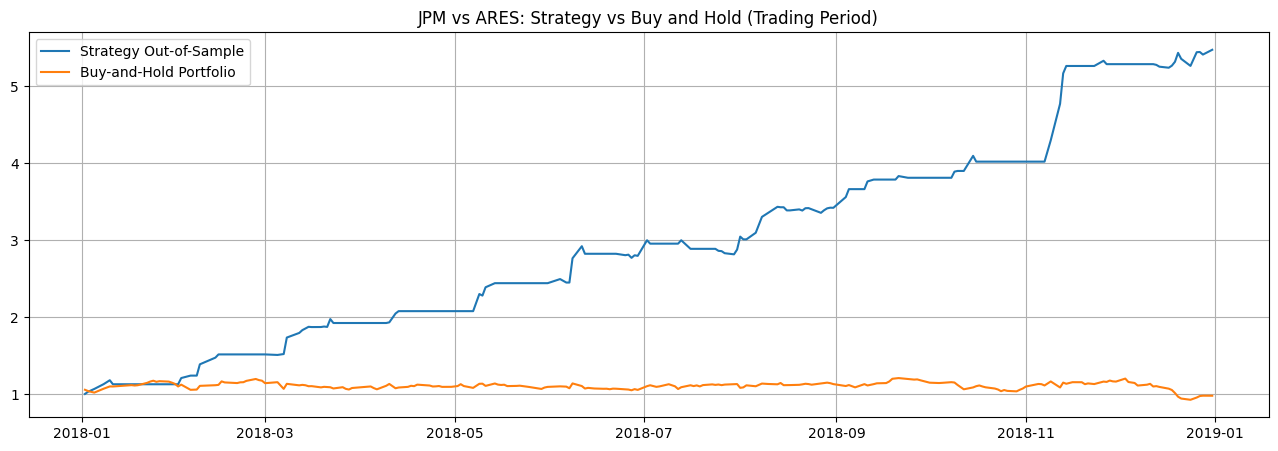

,JPM-ARES Algorithm,JPM-ARES Buy and Hold,JPM Indiv Stock,ARES Indiv Stock
Best day,0.141036,0.061396,0.136244,0.077092
Worst day,-0.044306,-0.075340,-0.116727,-0.116832
% days up,0.274336,0.495575,0.451327,0.469027
% days down,0.146018,0.500000,0.539823,0.500000
Avg gain,0.034500,0.015691,0.024373,0.016836
Std gain,0.033581,0.014466,0.028803,0.013475
Avg loss,-0.011138,-0.015320,-0.019929,-0.015813
Std loss,0.010565,0.013924,0.021439,0.016471
Total Return,4.472236,-0.073515,-0.150004,-0.064724
APR,5.710342,-0.081965,-0.166421,-0.072204


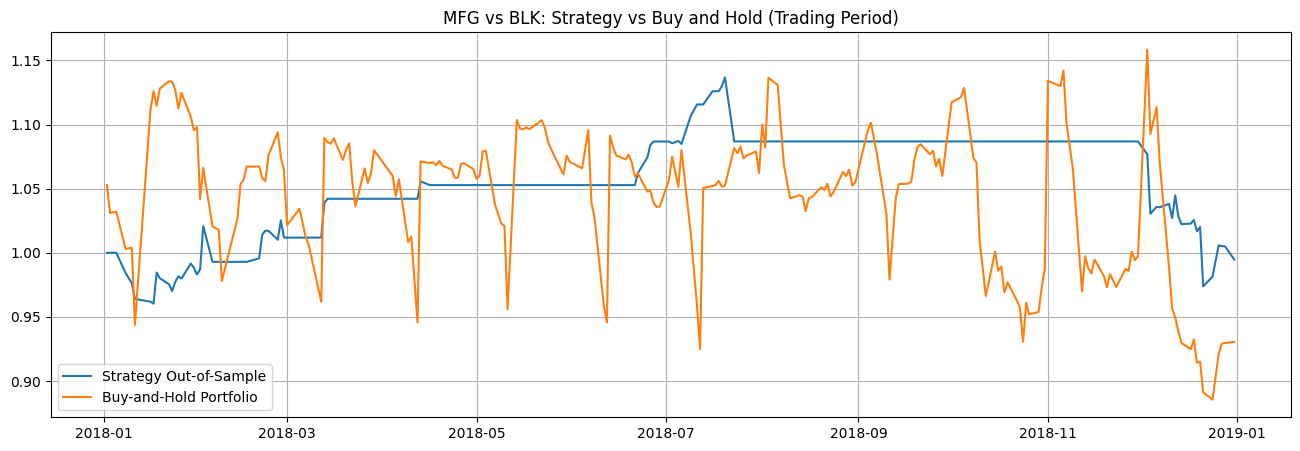

,MFG-BLK Algorithm,MFG-BLK Buy and Hold,MFG Indiv Stock,BLK Indiv Stock
Best day,0.034049,0.177600,0.044379,0.339893
Worst day,-0.045344,-0.090456,-0.045603,-0.175098
% days up,0.141593,0.469027,0.424779,0.446903
% days down,0.128319,0.530973,0.460177,0.553097
Avg gain,0.009812,0.022518,0.009729,0.043703
Std gain,0.008615,0.038904,0.007457,0.078913
Avg loss,-0.010775,-0.019281,-0.010315,-0.033031
Std loss,0.012728,0.019510,0.008984,0.039426
Total Return,-0.005297,-0.116195,-0.148961,-0.287416
APR,-0.005931,-0.129198,-0.165275,-0.315810


In [10]:
# Main loop for Pairs Trading
for i in range(len(cointegrated_pairs)):
    metrics_dict = {}
    
    # Get the stock names
    s1 = cointegrated_pairs.loc[i, 's1']
    s2 = cointegrated_pairs.loc[i, 's2']
    pair_label = f"{s1}-{s2}"

    # 1. Hedge ratio from training data (Formation Period)
    y_train = log_prices_form[s1]
    x_train = log_prices_form[s2]
    model = sm.OLS(y_train, sm.add_constant(x_train)).fit()
    hedge_ratio = model.params[1]

    # 2. Spread & Z-score in trading period
    spread_trade = log_prices_trade[s1] - hedge_ratio * log_prices_trade[s2]
    spread_mean = spread_trade.mean()
    spread_std = spread_trade.std()
    zscore_trade = (spread_trade - spread_mean) / spread_std

    # 3. Define entry & exit signals
    entry_signal = np.where(zscore_trade > 1, -1, np.where(zscore_trade < -1, 1, np.nan))
    exit_signal = np.where(np.abs(zscore_trade) <= 1, 0, np.nan)
    entry_signal[exit_signal == 0] = 0

    # 4. Build positions with the for-loop
    # ------------------------------------------------
    # For overall positions/spread: 
    # positions: -1 => short spread, +1 => long spread, 0 => flat
    # ------------------------------------------------
    #### Note 1: Short Spread = we need to short s1, long s2
    #### Note 2: Long Spread = We need to long s1, short s2
    # ------------------------------------------------
    # In terms of trading the two stocks: 
    # s1_trade, s2_trade: 2 => going short, 1 => going long, NaN => no position
    # ------------------------------------------------
    positions = pd.Series(entry_signal, index=zscore_trade.index).copy()
    s1_trade = pd.Series(index=zscore_trade.index, dtype=float)
    s2_trade = pd.Series(index=zscore_trade.index, dtype=float)

    for j in range(len(positions) - 1):
        ############ For the first day
        if j == 0:                  
            if entry_signal[j] == -1:
                s1_trade.iloc[j] = 2  # short s1
                s2_trade.iloc[j] = 1  # long s2
            elif entry_signal[j] == 1:
                s1_trade.iloc[j] = 1  # long s1
                s2_trade.iloc[j] = 2  # short s2
            else:
                s1_trade.iloc[j] = np.nan
                s2_trade.iloc[j] = np.nan

        ############# For all other days
        else:                             
            if entry_signal[j] == -1:
                s1_trade.iloc[j] = 2
                s2_trade.iloc[j] = 1
            elif entry_signal[j] == 1:
                s1_trade.iloc[j] = 1
                s2_trade.iloc[j] = 2

            # If we don't have a signal for a given day, we need to check the previous trade signal (Do we still have a position?)
            elif entry_signal[j] == 0:

                # If the previous signal was -1, we need to close the position by going long
                prev_signal = entry_signal[j-1]
                if prev_signal == -1:            # This means that we were shorting stock s1, longing stock s2
                    positions.iloc[j] = 1
                    s1_trade.iloc[j] = 1         # buying s1 back
                    s2_trade.iloc[j] = 2         # selling s2 to close the position

                # Same Logic
                elif prev_signal == 1:
                    positions.iloc[j] = -1
                    s1_trade.iloc[j] = 2
                    s2_trade.iloc[j] = 1
                    
                # Same Logic
                else:
                    # If we have no prior signal or missing, skip
                    positions.iloc[j] = np.nan
                    s1_trade.iloc[j] = np.nan
                    s2_trade.iloc[j] = np.nan
            else:
                s1_trade.iloc[j] = np.nan
                s2_trade.iloc[j] = np.nan

    # Make sure the last trading day is flat
    j = len(positions) - 1
    s1_trade.iloc[j] = np.nan
    s2_trade.iloc[j] = np.nan

    # 5. Convert individual trades signals (2 => short, 1 => long) into numeric signals
    s1_position = s1_trade.apply(lambda v: map_position(v, is_s2=False, hedge_ratio=1.0))
    s2_position = s2_trade.apply(lambda v: map_position(v, is_s2=True,  hedge_ratio=hedge_ratio))

    # 6. Shift positions to align with returns
    s1_pos_shifted = s1_position.shift(1).fillna(0)
    s2_pos_shifted = s2_position.shift(1).fillna(0)

    # 7. Compute daily returns from each leg
    strat_returns_s1 = s1_pos_shifted * returns_trade[s1] # => daily Profit/Loss from s1
    strat_returns_s2 = s2_pos_shifted * returns_trade[s2] # => daily Profit/Loss from s2
    strategy_returns = strat_returns_s1 + strat_returns_s2

    # 8. Cumulative performance
    pt_cumulative_returns = (strategy_returns + 1).cumprod()

    # 9. Compare with buy-and-hold
    bnh_returns, cumret_bnh = buy_and_hold_portfolio(s1, s2, returns_trade)

    # 10. Calculate metrics and plot
    strat_metrics = calculate_metrics_add(strategy_returns.dropna())
    strat_total, strat_apr, strat_sharpe = calculate_metrics(pt_cumulative_returns.dropna())
    strat_metrics.update({
        "Total Return": strat_total,
        "APR": strat_apr,
        "Sharpe": strat_sharpe
    })
    metrics_dict[f'{pair_label} Algorithm'] = strat_metrics

    #### Buy and Hold metrics
    bnh_metrics = calculate_metrics_add(bnh_returns.dropna())
    bnh_total, bnh_apr, bnh_sharpe = calculate_metrics(cumret_bnh.dropna())
    bnh_metrics.update({
        "Total Return": bnh_total,
        "APR": bnh_apr,
        "Sharpe": bnh_sharpe
    })
    metrics_dict[f'{pair_label} Buy and Hold'] = bnh_metrics

    #### s1 alone
    s1_ret = returns_trade[s1].dropna()
    s1_cumret = (s1_ret + 1).cumprod()
    s1_metrics = calculate_metrics_add(s1_ret)
    s1_total, s1_apr, s1_sharpe = calculate_metrics(s1_cumret.dropna())
    s1_metrics.update({
        "Total Return": s1_total,
        "APR": s1_apr,
        "Sharpe": s1_sharpe
    })
    metrics_dict[f'{s1} Indiv Stock'] = s1_metrics

    #### s2 alone
    s2_ret = returns_trade[s2].dropna()
    s2_cumret = (s2_ret + 1).cumprod()
    s2_metrics = calculate_metrics_add(s2_ret)
    s2_total, s2_apr, s2_sharpe = calculate_metrics(s2_cumret.dropna())
    s2_metrics.update({
        "Total Return": s2_total,
        "APR": s2_apr,
        "Sharpe": s2_sharpe
    })
    metrics_dict[f'{s2} Indiv Stock'] = s2_metrics

    # 11. Plot
    plt.figure(figsize=(16,5))
    plt.plot(pt_cumulative_returns, label='Strategy Out-of-Sample')
    plt.plot(cumret_bnh, label='Buy-and-Hold Portfolio')
    plt.title(f'{s1} vs {s2}: Strategy vs Buy and Hold (Trading Period)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 12. Print metrics
    metrics_df = pd.DataFrame(metrics_dict).round(6)
    display(metrics_df)